# Phase 5 — Which graph should GraphSAGE use?

## 1 · The question

Original graph, or a role-based one — `psi`, `degree`, `centrality`, `hybrid`?

- Only the graph changes. Encoder, features, K = 10, seeds 42/43/44 stay fixed.
- Each dataset × task gets one answer: keep original, tie, or augment.
- Can that answer be read off the graph's own properties?

Four paper-facing tables, in order: **Table 4** the full leaderboard, **Table 1** node classification, **Table 2** link prediction and its two candidate rules, **Table 3** the feature ablation. Every raw diagnostic sits in the appendix at the end.

One point per dataset, so this is a conjecture rather than a significance test. The three datasets added last were predicted in `docs/paper_log.md` before training.


## 2 · Inputs

Nothing is trained here. Every number is read back from what the study already wrote — scores from `results/scoreboard.csv`, graphs from `input/`, labels from `labels/`, features from `output/feature_cache/`. The work happens in `characterize.py`.

- Each task uses its own metric, so scores are only compared inside one dataset × task cell.

- Weighted F1 sits near its floor on `tolokers` and collapses on `questions` — both are badly imbalanced.

- `EXCLUDE` hides `citeseer_linqs` and `proteins` from this notebook only; nothing is deleted.


In [1]:
"""Setup: repo root, config, the characterization functions. Heavy lifting: experiments/characterize.py."""
import os, sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)                     # run everything from the repo root
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from virgo import config as cfg
from experiments.characterize import (STUDY, PREDICTORS, PREDICTORS_PRIMARY, GATES, graph_properties,
                          feature_properties, frozen_inputs, gaps, feature_scores, correlate, candidate_rules, nested_loo, threshold)

EXCLUDE = ["citeseer_linqs", "proteins"]            # hidden from THIS notebook only - files, embeddings and scoreboard rows are untouched; empty the list to bring one back
FAMILY = {"citation": "citation", "biological": "molecular", "drug interaction": "molecular",
          "crowdsourcing": "social interaction", "q&a interaction": "social interaction",
          "linguistic": "linguistic"}               # experiments.characterize.STUDY domain -> the four families the panel spans
DATASETS = [ds for ds in STUDY if ds not in EXCLUDE]              # every registered study dataset - the panel grows in experiments.characterize.STUDY, not in the cells below
ORDER = ["original", "psi", "degree", "centrality", "hybrid"]      # control first, then the four augmented graphs
cfg.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

# Saves a figure to results/figures/ and shows it.
def show(fig, name):
    """Save under results/figures/ and display."""
    fig.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

/home/m-adam/miniconda/envs/i2v/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""Read everything the study already produced - same six calls as `characterize.py --step all`."""
props = pd.DataFrame([graph_properties(ds) for ds in DATASETS])                  # what each dataset is like
dists = pd.DataFrame([r for ds in DATASETS for r in feature_properties(ds)])     # raw values fed to GraphSAGE
scores = frozen_inputs(DATASETS)                                                 # locked GraphSAGE scores, K=10, 3 seeds
gap = gaps(scores)                                                               # original vs best augmented, per cell
ablation = feature_scores(dists)                                                 # ablation D + each feature's raw spread
ablation = ablation[ablation["dataset"].isin(DATASETS)]                          # feature_scores reads the scoreboard directly, so apply EXCLUDE here too
corr = correlate(props, gap, ablation)                                           # Spearman, both scopes
cand = candidate_rules(props, gap)                                               # every property as an executable rule

print(f"{len(props)} datasets | {len(scores)} scores | {len(gap)} dataset x task cells "
      f"| {len(ablation)} ablation rows | {len(dists)} feature distributions")
print(f"excluded from this notebook: {EXCLUDE or 'none'} (still scored in results/scoreboard.csv)")

7 datasets | 60 scores | 12 dataset x task cells | 100 ablation rows | 28 feature distributions
excluded from this notebook: ['citeseer_linqs', 'proteins'] (still scored in results/scoreboard.csv)


## 3 · Table 4 — complete graph-variant leaderboard

Every variant's 3-seed mean ± std, side by side, one row per dataset × task cell.

- `winner` — highest mean. `verdict` — whether the best role graph clears the pooled seed noise (1σ).
- `gap_abs` is `best augmented − original` in that cell's own metric, so it is only read _within_ a row.
- Heatmap below shows the same numbers relative to the original graph.


In [ ]:
"""TABLE 4 - complete graph-variant leaderboard: every variant as mean +- std, the winner, the gap, the verdict."""
piv = scores.pivot(index=["dataset", "task"], columns="graph_variant", values="mean").reindex(columns=ORDER)
txt = (scores.assign(cell=[f"{m:.4f} ± {s:.4f}" for m, s in zip(scores["mean"], scores["std"])])
       .pivot(index=["dataset", "task"], columns="graph_variant", values="cell").reindex(columns=ORDER))

T4 = txt.join(gap.set_index(["dataset", "task"])[["metric", "gap_abs", "gap_sigma", "verdict"]])
T4["winner"] = piv.idxmax(axis=1)
T4 = T4[["metric"] + ORDER + ["winner", "gap_abs", "gap_sigma", "verdict"]].sort_index().reset_index()
T4.columns = ["dataset", "task", "metric"] + [f"{v} mean±std" for v in ORDER] + ["winner", "gap_abs", "gap_sigma", "verdict"]
display(T4)

n = gap["verdict"].value_counts()                                  # display() first so the tally prints BELOW the table
print(" | ".join(f"{v}: {n.get(v, 0)}" for v in ["keep original", "augment", "tie"]))
print("Metrics differ by task and protocol, so scores are compared only inside one row.")

,dataset,task,metric,original mean±std,psi mean±std,degree mean±std,centrality mean±std,hybrid mean±std,winner,gap_abs,gap_sigma,verdict
0,cora,link prediction (AUC),auc,0.6130 ± 0.0014,0.5150 ± 0.0038,0.5391 ± 0.0053,0.5659 ± 0.0056,0.5463 ± 0.0126,original,-0.0471,-11.54,keep original
1,cora,node classification (weighted F1),weighted_f1,0.4266 ± 0.0154,0.2351 ± 0.0085,0.2351 ± 0.0083,0.2942 ± 0.0153,0.2918 ± 0.0035,original,-0.1324,-8.63,keep original
2,enzymes,link prediction (AUC),auc,0.7000 ± 0.0086,0.6236 ± 0.0019,0.5484 ± 0.0133,0.6563 ± 0.0054,0.6322 ± 0.0018,original,-0.0437,-6.09,keep original
3,enzymes,node classification (weighted F1),weighted_f1,0.5591 ± 0.0075,0.5480 ± 0.0048,0.5474 ± 0.0058,0.5372 ± 0.0034,0.5546 ± 0.0059,original,-0.0045,-0.67,tie
4,ogbl_ddi,link prediction (OGB official),test_hits@20,0.0173 ± 0.0129,0.0423 ± 0.0143,0.0331 ± 0.0134,0.0519 ± 0.0127,0.0344 ± 0.0174,centrality,0.0346,2.70,augment
5,ogbn_arxiv,node classification (OGB official),test_acc,0.3918 ± 0.0060,0.2466 ± 0.0019,0.2416 ± 0.0032,0.2658 ± 0.0019,0.3618 ± 0.0032,original,-0.0300,-6.24,keep original
6,questions,link prediction (AUC),auc,0.4665 ± 0.0130,0.4923 ± 0.0251,0.5272 ± 0.0096,0.5078 ± 0.0240,0.5526 ± 0.0232,hybrid,0.0861,4.58,augment
7,questions,node classification (weighted F1),weighted_f1,0.9555 ± 0.0000,0.9554 ± 0.0000,0.9554 ± 0.0000,0.9554 ± 0.0000,0.9555 ± 0.0000,original,0.0000,NaN,keep original
8,roman_empire,link prediction (AUC),auc,0.6019 ± 0.0124,0.5407 ± 0.0027,0.5092 ± 0.0033,0.6980 ± 0.0139,0.5408 ± 0.0026,centrality,0.0961,7.30,augment
9,roman_empire,node classification (weighted F1),weighted_f1,0.2561 ± 0.0092,0.2069 ± 0.0018,0.2108 ± 0.0044,0.2093 ± 0.0049,0.2144 ± 0.0076,original,-0.0417,-4.94,keep original


keep original: 7 | augment: 4 | tie: 1
Metrics differ by task and protocol, so scores are compared only inside one row.


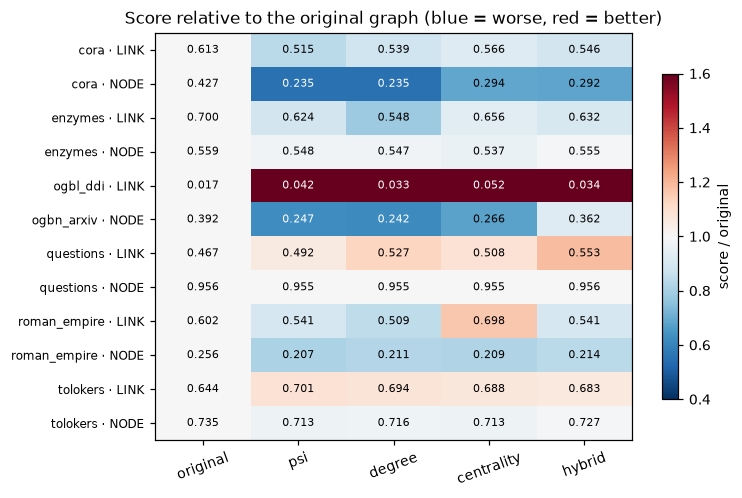

In [4]:
"""The same table as a picture: how far each variant lands from the original graph."""

ratio = piv.div(piv["original"], axis=0)



fig, ax = plt.subplots(figsize=(7, 4.6))

im = ax.imshow(ratio.values, cmap="RdBu_r", vmin=0.4, vmax=1.6, aspect="auto")

ax.grid(False)

ax.set_xticks(range(len(ORDER)), ORDER, rotation=20)

ax.set_yticks(range(len(piv)), [f"{d} · {t.split(' (')[0][:4].upper()}" for d, t in piv.index], fontsize=8)

for i in range(piv.shape[0]):                                   # annotate with the real score, colour carries the ratio

    for j in range(piv.shape[1]):

        dark = abs(ratio.values[i, j] - 1) > 0.35               # keep the label readable on saturated cells

        ax.text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center", fontsize=7.5,

                color="white" if dark else "black")

ax.set_title("Score relative to the original graph (blue = worse, red = better)")

fig.colorbar(im, ax=ax, label="score / original", shrink=0.8)

show(fig, "fig1_variant_vs_original")

## 4 · Table 1 — node-classification topology characterization

Node-classification cells only, each beside the label-topology properties that could explain it.

- `homophily_adjusted` / `nbr_predictability_adjusted` are corrected for class count and balance — raw values are not comparable across datasets.
- `nbr_label_entropy` — how mixed a node's neighbour labels are, 0 = pure, 1 = uniform.
- No threshold column: nothing augments, so there is no line to fit.


In [5]:
"""TABLE 1 - node-classification cells, with the two link-prediction rules applied to show they do NOT transfer."""
from virgo.frozen_rules import FROZEN_RULES
RULES = [(r.predictor, r.op, r.point) for r in FROZEN_RULES]   # THE frozen rules (virgo/frozen_rules.py) - single source, never re-fit in this notebook

# One rule on one dataset -> its prediction, or n/a when the property needs labels the graph does not have.
def predicts(v, op, t):
    """augment / keep original for one threshold rule; n/a when the value is missing."""
    return "n/a" if v != v else ("augment" if (v < t if op == "<" else v > t) else "keep original")

NC_PROPS = ["homophily_adjusted", "majority_class_frac", "n_classes", "components"]
T1 = gap[gap["task_family"] == "node classification"].merge(props, on="dataset")
for i, (c, op, t) in enumerate(RULES, start=1):
    T1[f"rule{i}_prediction"] = [predicts(v, op, t) for v in T1[c]]
T1 = (T1.rename(columns={"verdict": "actual_verdict"})
      [["dataset", "original", "best_augmented", "rule1_prediction", "rule2_prediction", "actual_verdict"] + NC_PROPS]
      .sort_values("homophily_adjusted", ascending=False).reset_index(drop=True))
display(T1.round(4))

print("No usable NC cell augmented; therefore no NC threshold can be learned.")
print("The current boundary recommendation is to retain the original graph.")
for i in (1, 2):                                        # the LP rules are shown here only to make that boundary visible
    wrong = int((T1[f"rule{i}_prediction"] != T1["actual_verdict"]).sum())
    print(f"  rule {i} applied to node classification: wrong on {wrong}/{len(T1)} cells - it is a LINK-PREDICTION rule and does not transfer.")
bad = gap[(gap["task_family"] == "node classification") & ~gap["usable"]]["dataset"].tolist()
print(f"Listed but not usable (metric has no resolution, excluded from every correlation): {bad or 'none'}")
print("nbr_predictability_adjusted and nbr_label_entropy are measured but shown in Appendix A2 - they explain")
print("roman_empire, whose neighbours agree BELOW chance yet still carry class information.")

,dataset,original,best_augmented,rule1_prediction,rule2_prediction,actual_verdict,homophily_adjusted,majority_class_frac,n_classes,components
0,cora,0.4266,0.2942,keep original,keep original,keep original,0.7711,0.3021,7,78
1,ogbn_arxiv,0.3918,0.3618,keep original,augment,keep original,0.5877,0.1613,40,1
2,enzymes,0.5591,0.5546,keep original,keep original,tie,0.3613,0.4949,3,640
3,tolokers,0.7345,0.7265,augment,augment,keep original,0.0926,0.7818,2,1
4,questions,0.9555,0.9555,augment,augment,keep original,0.0207,0.9702,2,1
5,roman_empire,0.2561,0.2144,augment,augment,keep original,-0.0468,0.1396,18,1


No usable NC cell augmented; therefore no NC threshold can be learned.
The current boundary recommendation is to retain the original graph.
  rule 1 applied to node classification: wrong on 4/6 cells - it is a LINK-PREDICTION rule and does not transfer.
  rule 2 applied to node classification: wrong on 5/6 cells - it is a LINK-PREDICTION rule and does not transfer.
Listed but not usable (metric has no resolution, excluded from every correlation): ['questions']
nbr_predictability_adjusted and nbr_label_entropy are measured but shown in Appendix A2 - they explain
roman_empire, whose neighbours agree BELOW chance yet still carry class information.


## 5 · Table 2 — link-prediction topology characterization

Every augment verdict in the study is a link-prediction cell, so this is where a rule can exist.

**Part A** — what each candidate rule predicts per dataset, next to what actually happened.  
**Part B** — all seven primary properties screened, and why only two were kept.  
**Part C** — the evidence behind the two retained candidates, including the out-of-sample refit.

- `rule1` — augment when adjusted homophily is low. `rule2` — augment when the graph is one connected piece.
- A cut is reported with the **interval** it sits in: every value inside fits the panel equally well.
- Scatterplots below plot the gap against both rule properties.


In [6]:
"""TABLE 2 PART A - what each candidate rule predicts per link-prediction dataset, and what actually happened."""
rows = []
for r in gap[(gap["task_family"] == "link prediction")].merge(props, on="dataset").itertuples():
    said = [predicts(getattr(r, c), op, t) for c, op, t in RULES]        # RULES and predicts() defined in Table 1
    live = [s for s in said if s != "n/a"]
    if len(set(live)) > 1:
        agree = "rules disagree"
    elif len(live) == 1:
        agree = ("rule 2 correct" if live[0] == r.verdict else "rule 2 WRONG") + " (rule 1 needs labels)"
    else:
        agree = "both rules correct" if live[0] == r.verdict else "both rules WRONG"
    rows.append({"dataset": r.dataset, "original": r.original, "best_augmented": r.best_augmented,
                 "rule1_prediction": said[0], "rule2_prediction": said[1], "actual_verdict": r.verdict,
                 "homophily_adjusted": r.homophily_adjusted,
                 "largest_component_frac": r.largest_component_frac, "agreement": agree})

T2a = pd.DataFrame(rows).sort_values("homophily_adjusted").reset_index(drop=True)
display(T2a.round(4))

for i in (1, 2):                                    # evaluable = the rule's property exists for that graph
    ev = T2a[T2a[f"rule{i}_prediction"] != "n/a"]
    print(f"  rule {i} applied to link prediction: wrong on {int((ev[f'rule{i}_prediction'] != ev['actual_verdict']).sum())}"
          f"/{len(ev)} evaluable cells" + (f" ({len(T2a) - len(ev)} cell has no labels to evaluate it on)" if len(ev) < len(T2a) else ""))
print("Both rules were fitted on these same six cells, so agreement here is the minimum they must reach, not evidence.")
print("Part C is the out-of-sample check: refit with one dataset hidden, each rule then makes exactly one error.")

,dataset,original,best_augmented,rule1_prediction,rule2_prediction,actual_verdict,homophily_adjusted,largest_component_frac,agreement
0,roman_empire,0.6019,0.6980,augment,augment,augment,-0.0468,1.0000,both rules correct
1,questions,0.4665,0.5526,augment,augment,augment,0.0207,1.0000,both rules correct
2,tolokers,0.6444,0.7007,augment,augment,augment,0.0926,1.0000,both rules correct
3,enzymes,0.7000,0.6563,keep original,keep original,keep original,0.3613,0.0064,both rules correct
4,cora,0.6130,0.5659,keep original,keep original,keep original,0.7711,0.9177,both rules correct
5,ogbl_ddi,0.0173,0.0519,n/a,augment,augment,NaN,1.0000,rule 2 correct (rule 1 needs labels)


  rule 1 applied to link prediction: wrong on 0/5 evaluable cells (1 cell has no labels to evaluate it on)
  rule 2 applied to link prediction: wrong on 0/6 evaluable cells
Both rules were fitted on these same six cells, so agreement here is the minimum they must reach, not evidence.
Part C is the out-of-sample check: refit with one dataset hidden, each rule then makes exactly one error.


In [ ]:
"""TABLE 2 PART B - screening all seven primary properties: what each scored, and why only two survived."""
lp = cand[cand["task_family"] == "link prediction"].set_index("predictor")
a, b = lp[lp["target"] == "gap_rel"], lp[lp["target"] == "gap_fixed_rel"]     # b = bias-free control gap

# The FIRST gate a property fails is its reason for being dropped; every gate is also a column, so nothing is hidden.
def why(p, r):
    """Plain-language reason one property was selected, merged away, or rejected."""
    if abs(r["spearman_rho"]) < GATES["min_abs_rho"]:
        return "correlation below screening gate"
    if not r["lodo_sign_stable"]:
        return "relationship changes direction when a dataset is removed"
    if r["n_exceptions"] > GATES["max_exceptions"]:
        return "too many threshold errors"
    if not r["loo_accuracy"] > r["majority_baseline"]:
        return "does not beat majority guessing"
    if not r["canonical"]:
        return "merged with largest_component_frac; same fragmentation signal, but LCF is scale-free"
    return ("SELECTED: strongest stable candidate" if p == "homophily_adjusted"
            else "SELECTED: supporting, label-free candidate")

rows = []
for p in PREDICTORS_PRIMARY:
    r, reason = a.loc[p], why(p, a.loc[p])
    rows.append({"candidate_property": p,
                 "impact_direction": ("lower" if r["augment_side"] == "low" else "higher") + " value -> augment",
                 "spearman_rho": r["spearman_rho"], "fixed_gap_rho": b.loc[p, "spearman_rho"],
                 "lodo_sign_stable": bool(r["lodo_sign_stable"]),
                 "loo_correct_folds": f"{r['loo_correct']}/{r['loo_folds']}",
                 "majority_baseline": r["majority_baseline"], "n_exceptions": int(r["n_exceptions"]),
                 "canonical": bool(r["canonical"]), "passes_gates": bool(r["credible"]),
                 "final_decision": ("SELECTED" if reason.startswith("SELECTED") else
                                    "merged" if not r["canonical"] else "rejected"),
                 "selection_reason": reason})

T2b = pd.DataFrame(rows)
T2b = (T2b.assign(_d=T2b["final_decision"].map({"SELECTED": 0, "merged": 1, "rejected": 2}),
                  _r=-T2b["spearman_rho"].abs())
       .sort_values(["_d", "_r"]).drop(columns=["_d", "_r"]).reset_index(drop=True))
display(T2b.round(4))
print("Seven properties screened, two kept: adjusted homophily leads, largest-component fraction supports it and is the")
print("only one evaluable on an unlabelled graph. Read a row left to right - the columns ARE the gates, and")
print("selection_reason names the first one the property fails. loo_correct_folds beats nothing unless it beats")
print("majority_baseline. nbr_predictability_adjusted clears every gate except that one, and the bias-free")
print("fixed_gap_rho (-0.60) does not reproduce its -0.70 either, so it is screened out rather than kept as a third rule.")

,candidate_property,impact_direction,spearman_rho,fixed_gap_rho,lodo_sign_stable,loo_correct_folds,majority_baseline,n_exceptions,canonical,passes_gates,final_decision,selection_reason
0,homophily_adjusted,lower value -> augment,-0.9000,-1.0000,True,4/5,0.6000,0,True,True,SELECTED,SELECTED: strongest stable candidate
1,largest_component_frac,higher value -> augment,0.7775,0.7775,True,5/6,0.6667,0,True,True,SELECTED,"SELECTED: supporting, label-free candidate"
2,components,lower value -> augment,-0.7775,-0.7775,True,5/6,0.6667,0,False,True,merged,merged with largest_component_frac; same fragm...
3,nbr_predictability_adjusted,lower value -> augment,-0.7000,-0.6000,True,3/5,0.6000,0,True,False,rejected,does not beat majority guessing
4,n_classes,lower value -> augment,-0.6088,-0.4058,True,4/6,0.6667,1,True,False,rejected,correlation below screening gate
5,avg_degree,higher value -> augment,0.4857,0.3143,True,4/6,0.6667,1,True,False,rejected,correlation below screening gate
6,avg_clustering,higher value -> augment,0.0857,0.2000,False,0/6,0.6667,2,True,False,rejected,correlation below screening gate


Seven properties screened, two kept: adjusted homophily leads, largest-component fraction supports it and is the
only one evaluable on an unlabelled graph. Read a row left to right - the columns ARE the gates, and
selection_reason names the first one the property fails. loo_correct_folds beats nothing unless it beats
majority_baseline. nbr_predictability_adjusted clears every gate except that one, and the bias-free
fixed_gap_rho (-0.60) does not reproduce its -0.70 either, so it is screened out rather than kept as a third rule.


In [8]:
"""TABLE 2 PART C - the evidence behind each retained link-prediction candidate, including the hidden-dataset refit."""
lp = cand[(cand["task_family"] == "link prediction") & cand["canonical"] & (cand["n_exceptions"] >= 0)]
a = lp[lp["target"] == "gap_rel"].set_index("predictor")
b = lp[lp["target"] == "gap_fixed_rel"].set_index("predictor")            # bias-free control: one variant pre-committed per task
a = a[(a["spearman_rho"].abs() >= GATES["min_abs_rho"]) | a["credible"]]  # the screened findings, kept and rejected alike
lead = b.loc[a[a["credible"]].index, "spearman_rho"].abs().idxmax()       # strongest on the bias-free gap
RANK = {"strongest candidate": 0, "supporting candidate - two-group split": 1, "REJECTED out of sample": 2}

rows = []
for p, r in a.iterrows():
    st = ("REJECTED out of sample" if not r["credible"] else
          "supporting candidate - two-group split" if r["distinct_augment"] <= 1 else
          "strongest candidate" if p == lead else "supporting candidate")
    rows.append({"candidate": f"augment when {p} is {r['augment_side']}",
                 "point_cutoff": r["threshold"],
                 "separating_interval": f"{r['interval_lo']} - {r['interval_hi']}",
                 "loo_correct_folds": f"{r['loo_correct']}/{r['loo_folds']}",
                 "loo_accuracy": r["loo_accuracy"], "majority_baseline": r["majority_baseline"],
                 "loo_threshold_range": f"{r['loo_threshold_lo']} - {r['loo_threshold_hi']}",
                 "spearman_rho": r["spearman_rho"], "fixed_gap_rho": b.loc[p, "spearman_rho"],
                 "lodo_min_abs_rho": r["lodo_min_abs_rho"], "p_bonferroni": b.loc[p, "p_bonferroni"], "status": st})

T2b = pd.DataFrame(rows).sort_values("status", key=lambda s: s.map(RANK)).reset_index(drop=True)
display(T2b.round(4))
print("point_cutoff is the MIDPOINT of separating_interval, not an exact or universal threshold: every cut inside the")
print("interval fits this panel equally well, and refitting with one dataset hidden moves it across loo_threshold_range.")
print("Compare loo_accuracy against majority_baseline, never against zero. p_bonferroni is quoted on the bias-free")
print("fixed-gap rho, corrected within the 7 primary predictors. Candidates awaiting Module 3, not proven rules.")

,candidate,point_cutoff,separating_interval,loo_correct_folds,loo_accuracy,majority_baseline,loo_threshold_range,spearman_rho,fixed_gap_rho,lodo_min_abs_rho,p_bonferroni,status
0,augment when homophily_adjusted is low,0.2270,0.0926 - 0.3613,4/5,0.8000,0.6000,0.191 - 0.4319,-0.9000,-1.0000,0.8000,0.1169,strongest candidate
1,augment when largest_component_frac is high,0.9588,0.9177 - 1.0,5/6,0.8333,0.6667,0.5032 - 0.9588,0.7775,0.7775,0.7071,0.4809,supporting candidate - two-group split
2,augment when nbr_predictability_adjusted is low,0.4084,0.3324 - 0.4844,3/5,0.6000,0.6000,0.2402 - 0.5734,-0.7000,-0.6000,0.4000,1.0000,REJECTED out of sample


point_cutoff is the MIDPOINT of separating_interval, not an exact or universal threshold: every cut inside the
interval fits this panel equally well, and refitting with one dataset hidden moves it across loo_threshold_range.
Compare loo_accuracy against majority_baseline, never against zero. p_bonferroni is quoted on the bias-free
fixed-gap rho, corrected within the 7 primary predictors. Candidates awaiting Module 3, not proven rules.


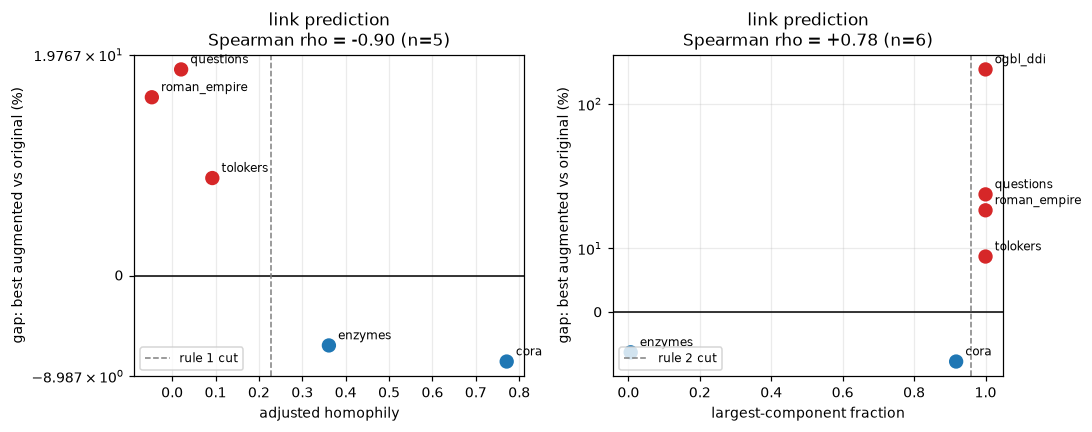

In [9]:
"""The link-prediction gap against both rule properties - the picture behind Table 2."""
J = gap[gap["task_family"] == "link prediction"].merge(props, on="dataset")
PANELS = [("homophily_adjusted", "adjusted homophily", 0.227, "rule 1 cut"),
          ("largest_component_frac", "largest-component fraction", 0.9588, "rule 2 cut")]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (prop, label, cut, tag) in zip(axes, PANELS):
    g = J.dropna(subset=[prop])
    r = corr[(corr["task_family"] == "link prediction") & (corr["predictor"] == prop)
             & (corr["target"] == "gap_rel")].iloc[0]
    ax.axhline(0, color="k", lw=1)
    ax.axvline(cut, color="grey", ls="--", lw=1, label=tag)
    ax.scatter(g[prop], 100 * g["gap_rel"], s=70, c=["tab:red" if v > 0 else "tab:blue" for v in g["gap_rel"]], zorder=3)
    for _, row in g.iterrows():
        ax.annotate(row["dataset"], (row[prop], 100 * row["gap_rel"]), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)
    ax.set_yscale("symlog", linthresh=20)      # ddi's +200% is a floor effect (original = 0.017), so compress it
    ax.set(xlabel=label, ylabel="gap: best augmented vs original (%)",
           title=f"link prediction\nSpearman rho = {r.spearman_rho:+.2f} (n={r.n})")
    ax.legend(fontsize=8, loc="lower left")
show(fig, "fig2_gap_vs_predictor")

## 6 · Table 3 — node-feature ablation

Which of the four structural inputs carries the signal. **Ablation D: the `psi` graph, K = 10, seeds 42/43/44** — the graph is held fixed and only the feature matrix changes.

- `random` — the same message passing with the structural signal replaced by noise. It is the control every other column is read against.
- `all_four` — the locked ViRGo-SAGE setting. `best_single` — strongest one-feature arm, `lift_vs_random` its margin over the control.
- `status` — whether that margin clears the pooled seed noise on a 2σ band. The `deg_cent` and `const` arms are in the appendix.


In [ ]:
"""TABLE 3 - ablation D on the psi graph at K=10: random control, each single feature, all four together."""
SINGLE = ["degree", "centrality", "psi", "clustering"]
KEEP_ARMS = ["random"] + SINGLE + ["all"]
A = ablation[ablation["arm"].isin(KEEP_ARMS)]
T3 = A.pivot_table(index=["dataset", "task"], columns="arm", values="mean").reindex(columns=KEEP_ARMS)

best = A[A["arm"].isin(SINGLE)].loc[A[A["arm"].isin(SINGLE)].groupby(["dataset", "task"])["mean"].idxmax()]
best = best.set_index(["dataset", "task"])
T3["best_single"] = best["arm"]
T3["lift_vs_random"] = best["lift_vs_random"]
T3["status"] = best["vs_random_features"]
T3 = T3.rename(columns={"all": "all_four"}).sort_index().reset_index()
T3.columns.name = None
display(T3.round(4))

print("Ablation D: psi graph, K = 10, 3 seeds. Only the feature matrix changes between columns.")
print("'metric constant' = the metric never moved for any arm (questions node classification, 97% majority class).")

,dataset,task,random,degree,centrality,psi,clustering,all_four,best_single,lift_vs_random,status
0,cora,link prediction (AUC),0.5134,0.4960,0.4349,0.4594,0.5298,0.5150,clustering,0.0164,tied with random
1,cora,node classification (weighted F1),0.1497,0.2153,0.2328,0.1743,0.1791,0.2351,centrality,0.0831,beats random
2,enzymes,link prediction (AUC),0.5103,0.5468,0.6498,0.6385,0.5320,0.6236,centrality,0.1395,beats random
3,enzymes,node classification (weighted F1),0.4789,0.5019,0.5117,0.5002,0.5401,0.5480,clustering,0.0612,beats random
4,ogbl_ddi,link prediction (OGB official),0.0005,0.0291,0.0368,0.0347,0.0118,0.0423,centrality,0.0363,beats random
5,ogbn_arxiv,node classification (OGB official),0.0586,0.1925,0.2530,0.1746,0.1069,0.2466,centrality,0.1944,beats random
6,questions,link prediction (AUC),0.4970,0.3638,0.4630,0.4062,0.4464,0.4923,centrality,-0.0340,worse than random
7,questions,node classification (weighted F1),0.9555,0.9554,0.9555,0.9555,0.9555,0.9554,centrality,0.0000,metric constant
8,roman_empire,link prediction (AUC),0.5570,0.5419,0.5312,0.5514,0.5471,0.5407,psi,-0.0056,tied with random
9,roman_empire,node classification (weighted F1),0.0707,0.1378,0.0469,0.0931,0.1719,0.2069,clustering,0.1012,beats random


Ablation D: psi graph, K = 10, 3 seeds. Only the feature matrix changes between columns.
'metric constant' = the metric never moved for any arm (questions node classification, 97% majority class).


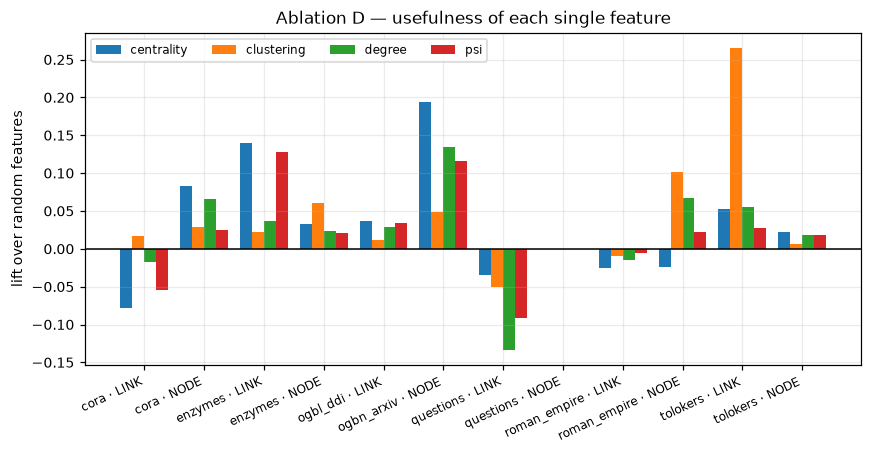

In [11]:
"""Ablation D lift over the random-feature control, per dataset x task."""

S = ablation[ablation["feature"].notna()].copy()

S["cell"] = S["dataset"] + " · " + S["task_family"].str.split(" ").str[0].str.upper()

L = S.pivot(index="cell", columns="arm", values="lift_vs_random").sort_index()



fig, ax = plt.subplots(figsize=(8, 4.2))

x = np.arange(len(L))

for i, arm in enumerate(L.columns):

    ax.bar(x + (i - 1.5) * 0.2, L[arm], width=0.2, label=arm)

ax.axhline(0, color="k", lw=1)

ax.set_xticks(x, L.index, rotation=25, ha="right", fontsize=8)

ax.set(ylabel="lift over random features", title="Ablation D — usefulness of each single feature")

ax.legend(fontsize=8, ncol=4, loc="upper left")

show(fig, "fig4_feature_lift")

---

# Appendix — Full diagnostic outputs

Everything the four tables above are read off. Nothing here is new evidence; it is the unsummarized form.


### A1 · Complete property table

Every measured property of every original graph, grouped into the four families the panel spans. Also in `results/dataset_characterization.csv`.


In [ ]:
"""The properties that will explain the results; sorted by average degree, the axis the panel spans widest."""

COLS = ["nodes", "avg_degree", "density", "avg_clustering",

        "components", "largest_component_frac", "n_classes", "homophily_adjusted"]

fam = props.assign(family=props["domain"].map(FAMILY))                          # four families: citation, molecular, social interaction, linguistic

fam = fam.sort_values(["family", "avg_degree"]).set_index(["family", "domain", "dataset"])

fam[COLS]

nodes  avg_degree  \
family             domain           dataset                            
citation           citation         cora            2708      3.8981   
                                    ogbn_arxiv    169343     13.6740   
linguistic         linguistic       roman_empire   22662      2.9059   
molecular          biological       enzymes        19474      3.8289   
                   drug interaction ogbl_ddi        4267    500.5442   
social interaction q&a interaction  questions      48921      6.2771   
                   crowdsourcing    tolokers       11758     88.2803   

                                                   density  avg_clustering  \
family             domain           dataset                                  
citation           citation         cora          0.001440          0.2407   
                                    ogbn_arxiv    0.000081          0.2261   
linguistic         linguistic       roman_empire  0.000128          0.3859   
molecular          biological       enzymes       0.000197          0.4024   
                   drug interaction ogbl_ddi      0.117333          0.5143   
social interaction q&a interaction  questions     0.000128          0.0307   
                   crowdsourcing    tolokers      0.007509          0.5329   

                                                  components  \
family             domain           dataset                    
citation           citation         cora                  78   
                                    ogbn_arxiv             1   
linguistic         linguistic       roman_empire           1   
molecular          biological       enzymes              640   
                   drug interaction ogbl_ddi               1   
social interaction q&a interaction  questions              1   
                   crowdsourcing    tolokers               1   

                                                  largest_component_frac  \
family             domain           dataset                                
citation           citation         cora                          0.9177   
                                    ogbn_arxiv                    1.0000   
linguistic         linguistic       roman_empire                  1.0000   
molecular          biological       enzymes                       0.0064   
                   drug interaction ogbl_ddi                      1.0000   
social interaction q&a interaction  questions                     1.0000   
                   crowdsourcing    tolokers                      1.0000   

                                                  n_classes  \
family             domain           dataset                   
citation           citation         cora                  7   
                                    ogbn_arxiv           40   
linguistic         linguistic       roman_empire         18   
molecular          biological       enzymes               3   
                   drug interaction ogbl_ddi              0   
social interaction q&a interaction  questions             2   
                   crowdsourcing    tolokers              2   

                                                  homophily_adjusted  
family             domain           dataset                           
citation           citation         cora                      0.7711  
                                    ogbn_arxiv                0.5877  
linguistic         linguistic       roman_empire             -0.0468  
molecular          biological       enzymes                   0.3613  
                   drug interaction ogbl_ddi                     NaN  
social interaction q&a interaction  questions                 0.0207  
                   crowdsourcing    tolokers                  0.0926

### A2 · Complete correlation table

Spearman ρ for every predictor against both gap definitions, per task. Primary-tier rows are the only ones that may gate a rule; exploratory rows are measured and reported, never promoted. Also in `results/characterization_correlations.csv`.


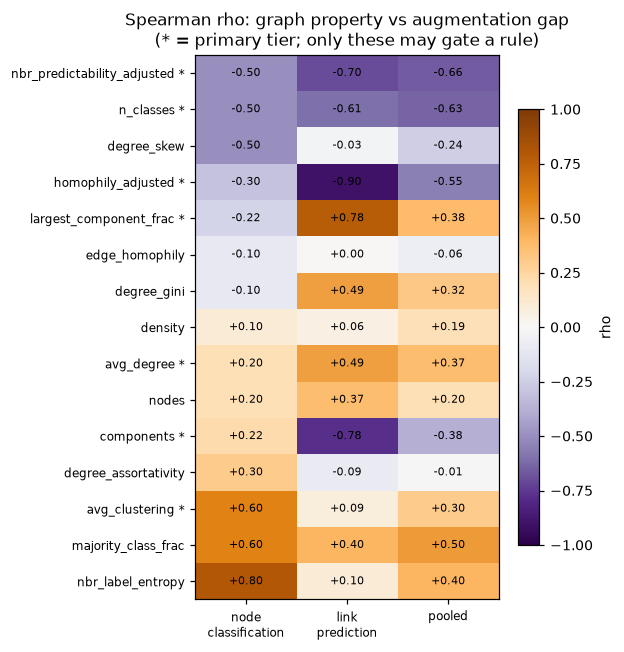

In [13]:
"""Every property against the gap, both tasks - the evidence behind the two panels above."""

H = (corr[corr["scope"].str.startswith("graph") & (corr["target"] == "gap_rel")]

     .pivot(index="predictor", columns="task_family", values="spearman_rho")

     .reindex(PREDICTORS)[["node classification", "link prediction", "pooled"]])

H = H.sort_values("node classification")



fig, ax = plt.subplots(figsize=(5.6, 6.0))

im = ax.imshow(H.values, cmap="PuOr_r", vmin=-1, vmax=1, aspect="auto")

ax.grid(False)

ax.set_xticks(range(H.shape[1]), [c.replace(" ", "\n") for c in H.columns], fontsize=8)

ax.set_yticks(range(len(H)), [f"{p} *" if p in PREDICTORS_PRIMARY else p for p in H.index], fontsize=8)  # * = primary tier

for i in range(H.shape[0]):

    for j in range(H.shape[1]):

        ax.text(j, i, f"{H.values[i, j]:+.2f}", ha="center", va="center", fontsize=7.5)

ax.set_title("Spearman rho: graph property vs augmentation gap\n(* = primary tier; only these may gate a rule)")

fig.colorbar(im, ax=ax, label="rho", shrink=0.8)

show(fig, "fig3_property_correlations")

In [ ]:
"""A2 - every predictor against both gap definitions, both tasks, primary and exploratory tiers."""
full_corr = (corr[corr["scope"].str.startswith("graph")]
             .sort_values(["task_family", "tier", "target", "predictor"])
             [["task_family", "tier", "target", "predictor", "n", "spearman_rho", "p_value",
               "p_bonferroni", "survives_correction"]].reset_index(drop=True))
display(full_corr.round(4))
print(f"{len(full_corr)} rows | Bonferroni is applied WITHIN the primary tier only ({len(PREDICTORS_PRIMARY)} tests).")

,task_family,tier,target,predictor,n,spearman_rho,p_value,p_bonferroni,survives_correction
0,link prediction,exploratory,gap_fixed_rel,degree_assortativity,6,0.0857,0.8717,NaN,False
1,link prediction,exploratory,gap_fixed_rel,degree_gini,6,0.2571,0.6228,NaN,False
2,link prediction,exploratory,gap_fixed_rel,degree_skew,6,-0.2000,0.7040,NaN,False
3,link prediction,exploratory,gap_fixed_rel,density,6,0.0580,0.9131,NaN,False
4,link prediction,exploratory,gap_fixed_rel,edge_homophily,5,-0.4000,0.5046,NaN,False
...,...,...,...,...,...,...,...,...,...
85,pooled,primary,gap_rel,components,11,-0.3814,0.2471,1.0000,False
86,pooled,primary,gap_rel,homophily_adjusted,10,-0.5522,0.0979,0.6853,False
87,pooled,primary,gap_rel,largest_component_frac,11,0.3814,0.2471,1.0000,False
88,pooled,primary,gap_rel,n_classes,11,-0.6329,0.0366,0.2562,False


90 rows | Bonferroni is applied WITHIN the primary tier only (7 tests).


### A3 · Raw candidate-rule screen

All 28 screened rows — every primary predictor × task × gap definition, kept and rejected alike. Also in `results/candidate_rules.csv`.


In [ ]:
"""Screen every primary property as a binary keep-vs-augment rule, both gap definitions."""

cand = candidate_rules(props, gap)



display(cand[["task_family", "target", "predictor", "predictor_family", "canonical", "n_cells", "n_augment",

              "distinct_augment", "spearman_rho", "p_bonferroni", "lodo_min_abs_rho", "lodo_sign_stable",

              "threshold", "interval_lo", "interval_hi", "augment_side", "n_exceptions",

              "loo_accuracy", "majority_baseline", "credible"]].round(4))



keep = cand[cand["credible"] & cand["canonical"]]                  # one row per FINDING: collinear predictors collapse to one

print("CREDIBLE FINDINGS: " + ("; ".join(dict.fromkeys(keep["rule"])) if len(keep) else "none clear the gates"))

thin = keep[keep["distinct_augment"] <= 1]["predictor"].unique()   # every augmenting graph at one value = group label, not a trend

if len(thin):

    print("WEAK - two-group split, not a graded trend: " + ", ".join(thin))

# Passes every in-sample gate, fails only when refitted with a dataset hidden - the case §8c exists to catch.

near = cand[~cand["credible"] & (cand["spearman_rho"].abs() >= GATES["min_abs_rho"]) & cand["lodo_sign_stable"]

            & cand["n_exceptions"].between(0, GATES["max_exceptions"])]

for r in near.drop_duplicates("rule").itertuples():

    print(f"REJECTED out of sample - {r.rule}: leave-one-out {r.loo_accuracy} vs {r.majority_baseline} for guessing the majority")

for name, sub in cand.groupby("task_family"):                      # a family with no augment cell has nothing to separate

    if sub["n_augment"].max() == 0:

        print(f"{name}: no augment cell exists -> only the boundary 'never augment' is reportable, not a rule")

,task_family,target,predictor,predictor_family,canonical,n_cells,n_augment,distinct_augment,spearman_rho,p_bonferroni,lodo_min_abs_rho,lodo_sign_stable,threshold,interval_lo,interval_hi,augment_side,n_exceptions,loo_accuracy,majority_baseline,credible
0,link prediction,gap_fixed_rel,avg_clustering,avg_clustering,True,6,4,4,0.2000,1.0000,0.1000,False,0.3133,0.2407,0.3859,high,2,0.0000,0.6667,False
1,link prediction,gap_fixed_rel,avg_degree,avg_degree,True,6,4,4,0.3143,1.0000,0.2000,False,5.0876,3.8981,6.2771,high,1,0.6667,0.6667,False
2,link prediction,gap_fixed_rel,components,fragmentation,False,6,4,1,-0.7775,0.4809,0.7071,True,39.5000,1.0000,78.0000,low,0,0.8333,0.6667,True
3,link prediction,gap_fixed_rel,homophily_adjusted,homophily_adjusted,True,5,3,3,-1.0000,0.1169,1.0000,True,0.2270,0.0926,0.3613,low,0,0.8000,0.6000,True
4,link prediction,gap_fixed_rel,largest_component_frac,fragmentation,True,6,4,1,0.7775,0.4809,0.7071,True,0.9588,0.9177,1.0000,high,0,0.8333,0.6667,True
5,link prediction,gap_fixed_rel,n_classes,n_classes,True,6,4,3,-0.4058,1.0000,0.0513,False,2.5000,2.0000,3.0000,low,1,0.6667,0.6667,False
6,link prediction,gap_fixed_rel,nbr_predictability_adjusted,nbr_predictability_adjusted,True,5,3,3,-0.6000,1.0000,0.2000,True,0.4084,0.3324,0.4844,low,0,0.6000,0.6000,False
7,link prediction,gap_rel,avg_clustering,avg_clustering,True,6,4,4,0.0857,1.0000,0.0000,False,0.3133,0.2407,0.3859,high,2,0.0000,0.6667,False
8,link prediction,gap_rel,avg_degree,avg_degree,True,6,4,4,0.4857,1.0000,0.1000,True,5.0876,3.8981,6.2771,high,1,0.6667,0.6667,False
9,link prediction,gap_rel,components,fragmentation,False,6,4,1,-0.7775,0.4809,0.7071,True,39.5000,1.0000,78.0000,low,0,0.8333,0.6667,True


CREDIBLE FINDINGS: link prediction: augment when homophily_adjusted is low (< 0.227); link prediction: augment when largest_component_frac is high (> 0.9588)
WEAK - two-group split, not a graded trend: largest_component_frac
REJECTED out of sample - link prediction: augment when nbr_predictability_adjusted is low (< 0.4084): leave-one-out 0.6 vs 0.6 for guessing the majority
node classification: no augment cell exists -> only the boundary 'never augment' is reportable, not a rule


### A4 · Fixed-gap details

The selection-bias control. `gap` above takes the best of four augmented variants, which is biased upward; `gap_fixed` repeats every comparison against **one** variant pre-committed per task (LP `centrality`, NC `hybrid`). If the two disagree anywhere, the headline verdict rode the max.


In [ ]:
"""A4 - the max-over-variants selection-bias control: best-of-four vs one pre-committed variant per task."""
fx = gap[["dataset", "task_family", "metric", "original", "best_variant", "gap_abs", "gap_sigma", "verdict",
          "fixed_variant", "fixed_augmented", "gap_fixed_abs", "gap_fixed_sigma", "verdict_fixed",
          "verdict_agrees", "usable"]].sort_values(["task_family", "dataset"]).reset_index(drop=True)
display(fx.round(4))
print(f"verdicts agree on {int(fx['verdict_agrees'].sum())}/{len(fx)} cells -> no augment verdict is an artefact of taking the max.")
print(f"unusable cells (excluded from every correlation): {fx.loc[~fx['usable'], 'dataset'].tolist() or 'none'}")

,dataset,task_family,metric,original,best_variant,gap_abs,gap_sigma,verdict,fixed_variant,fixed_augmented,gap_fixed_abs,gap_fixed_sigma,verdict_fixed,verdict_agrees,usable
0,cora,link prediction,auc,0.6130,centrality,-0.0471,-11.54,keep original,centrality,0.5659,-0.0471,-11.54,keep original,True,True
1,enzymes,link prediction,auc,0.7000,centrality,-0.0437,-6.09,keep original,centrality,0.6563,-0.0437,-6.09,keep original,True,True
2,ogbl_ddi,link prediction,test_hits@20,0.0173,centrality,0.0346,2.70,augment,centrality,0.0519,0.0346,2.70,augment,True,True
3,questions,link prediction,auc,0.4665,hybrid,0.0861,4.58,augment,centrality,0.5078,0.0413,2.14,augment,True,True
4,roman_empire,link prediction,auc,0.6019,centrality,0.0961,7.30,augment,centrality,0.6980,0.0961,7.30,augment,True,True
5,tolokers,link prediction,auc,0.6444,psi,0.0563,4.18,augment,centrality,0.6880,0.0436,3.14,augment,True,True
6,cora,node classification,weighted_f1,0.4266,centrality,-0.1324,-8.63,keep original,hybrid,0.2918,-0.1348,-12.07,keep original,True,True
7,enzymes,node classification,weighted_f1,0.5591,hybrid,-0.0045,-0.67,tie,hybrid,0.5546,-0.0045,-0.67,tie,True,True
8,ogbn_arxiv,node classification,test_acc,0.3918,hybrid,-0.0300,-6.24,keep original,hybrid,0.3618,-0.0300,-6.24,keep original,True,True
9,questions,node classification,weighted_f1,0.9555,hybrid,0.0000,NaN,keep original,hybrid,0.9555,0.0000,NaN,keep original,True,False


verdicts agree on 12/12 cells -> no augment verdict is an artefact of taking the max.
unusable cells (excluded from every correlation): ['questions']


### A5 · Individual leave-one-out folds

Table 2 Part C reports these folds as one accuracy. Here each fold is shown: which dataset was hidden, where the cut moved once it was gone, and what the remaining datasets then predicted for it.

The second table is the **nested** version — the predictor is re-chosen inside each fold too, so choosing it on all cells is scored as well. A dataset the fold's predictor cannot be evaluated on counts as a miss. Also in `results/nested_loo.csv`.


In [ ]:
"""A5 - every leave-one-out fold for the kept rules, then the nested version from results/nested_loo.csv."""
keep = cand[cand["credible"] & cand["canonical"]].drop_duplicates("rule")     # a rule clearing both gap definitions is ONE rule
d = gap[(gap["task_family"] == "link prediction") & gap["usable"] & (gap["verdict"] != "tie")].merge(props, on="dataset")

folds = []
for r in keep.itertuples():
    s = d[d[r.predictor].notna()]
    x, y = s[r.predictor].to_numpy(), (s["verdict"] == "augment").to_numpy()
    for i in range(len(x)):
        m = np.ones(len(x), dtype=bool)
        m[i] = False
        t, side, _, _, _, _ = threshold(x[m], y[m])                           # refit on the remaining datasets only
        said = (x[i] > t) if side == "high" else (x[i] < t)
        folds.append({"rule": r.predictor, "hidden_dataset": s["dataset"].iloc[i], "value": round(float(x[i]), 4),
                      "cut_refitted_without_it": t, "predicted": "augment" if said else "keep original",
                      "actual": s["verdict"].iloc[i], "correct": bool(said == y[i])})
display(pd.DataFrame(folds))

nest = nested_loo(props, gap)
display(nest[["task_family", "target", "held_out", "picked_predictor", "threshold",
              "value", "predicted", "actual", "correct"]].round(4))
for (family, target), sub in nest.groupby(["task_family", "target"]):
    print(f"nested LOO | {family} / {target}: {int(sub['correct'].sum())}/{len(sub)} correct, "
          f"picked {' + '.join(sorted(set(sub['picked_predictor'])))}")

,rule,hidden_dataset,value,cut_refitted_without_it,predicted,actual,correct
0,homophily_adjusted,cora,0.7711,0.2270,keep original,keep original,True
1,homophily_adjusted,enzymes,0.3613,0.4319,augment,keep original,False
2,homophily_adjusted,questions,0.0207,0.2270,augment,augment,True
3,homophily_adjusted,roman_empire,-0.0468,0.2270,augment,augment,True
4,homophily_adjusted,tolokers,0.0926,0.1910,augment,augment,True
5,largest_component_frac,cora,0.9177,0.5032,augment,keep original,False
6,largest_component_frac,enzymes,0.0064,0.9588,keep original,keep original,True
7,largest_component_frac,ogbl_ddi,1.0000,0.9588,augment,augment,True
8,largest_component_frac,questions,1.0000,0.9588,augment,augment,True
9,largest_component_frac,roman_empire,1.0000,0.9588,augment,augment,True


,task_family,target,held_out,picked_predictor,threshold,value,predicted,actual,correct
0,link prediction,gap_rel,cora,homophily_adjusted,0.2270,0.7711,keep original,keep original,True
1,link prediction,gap_rel,enzymes,homophily_adjusted,0.4319,0.3613,augment,keep original,False
2,link prediction,gap_rel,ogbl_ddi,homophily_adjusted,0.2270,NaN,n/a,augment,False
3,link prediction,gap_rel,questions,homophily_adjusted,0.2270,0.0207,augment,augment,True
4,link prediction,gap_rel,roman_empire,homophily_adjusted,0.2270,-0.0468,augment,augment,True
5,link prediction,gap_rel,tolokers,nbr_predictability_adjusted,0.4084,-0.3274,augment,augment,True
6,link prediction,gap_fixed_rel,cora,homophily_adjusted,0.2270,0.7711,keep original,keep original,True
7,link prediction,gap_fixed_rel,enzymes,homophily_adjusted,0.4319,0.3613,augment,keep original,False
8,link prediction,gap_fixed_rel,ogbl_ddi,homophily_adjusted,0.2270,NaN,n/a,augment,False
9,link prediction,gap_fixed_rel,questions,homophily_adjusted,0.2270,0.0207,augment,augment,True


nested LOO | link prediction / gap_fixed_rel: 4/6 correct, picked homophily_adjusted
nested LOO | link prediction / gap_rel: 4/6 correct, picked homophily_adjusted + nbr_predictability_adjusted


### A6 · Raw feature distributions

The four structural inputs as GraphSAGE actually receives them, before z-normalization. Also in `results/node_feature_characterization.csv`.

Do **not** read the `degenerate` boolean as a usefulness verdict — A7 below shows raw spread does not predict usefulness.


In [ ]:
"""A6 - the raw per-node feature distributions fed to the encoder, before z-normalization."""
display(dists[["dataset", "feature", "nodes", "mean", "std", "skew", "pct_zero", "pct_unique",
               "min", "max", "degenerate"]].round(4))

,dataset,feature,nodes,mean,std,skew,pct_zero,pct_unique,min,max,degenerate
0,cora,degree,2708,3.8981,5.2278,15.2714,0.00,1.3663,1.0000,168.0000,False
1,cora,eigenvector_centrality,2708,0.0772,0.2459,3.2902,2.62,87.0753,0.0000,1.0000,False
2,cora,psi,2708,-14.2669,31.7401,-16.6766,0.00,82.5332,-1097.9605,-1.0000,False
3,cora,clustering,2708,0.2407,0.3220,1.3077,45.72,4.8375,0.0000,1.0000,False
4,enzymes,degree,19474,3.8289,1.1161,0.3976,0.00,0.0462,1.0000,9.0000,True
5,enzymes,eigenvector_centrality,19474,0.3346,0.3220,0.6219,0.09,85.3035,0.0000,1.0000,False
6,enzymes,psi,19474,-59.2283,60.3102,-0.5329,0.00,45.8817,-261.4810,-1.0060,False
7,enzymes,clustering,19474,0.4024,0.2979,0.3818,19.68,0.2208,0.0000,1.0000,True
8,ogbn_arxiv,degree,169343,13.6740,68.6381,106.1425,0.00,0.3230,1.0000,13161.0000,True
9,ogbn_arxiv,eigenvector_centrality,169343,0.0020,0.0064,47.7474,24.84,96.0282,0.0000,1.0000,False


### A7 · Every feature-ablation arm

All arms including `deg_cent`, `const` and `none_mp`, which Table 3 leaves out. Also in `results/feature_usefulness.csv`.

The figure repeats the test the `degenerate` flag would have to pass: how spread out a feature's raw values are says nothing about whether it helps.


In [ ]:
"""A7 - every ablation arm on the psi graph, including the ones Table 3 omits."""
display(ablation[["dataset", "task", "arm", "feature", "metric", "mean", "std", "lift_vs_random",
                  "lift_sigma", "vs_random_features"]].sort_values(["dataset", "task", "arm"])
        .reset_index(drop=True).round(4))
print(f"{ablation['arm'].nunique()} arms: " + ", ".join(sorted(ablation["arm"].unique())))

,dataset,task,arm,feature,metric,mean,std,lift_vs_random,lift_sigma,vs_random_features
0,cora,link prediction (AUC),all,NaN,auc,0.5150,0.0038,0.0016,0.25,tied with random
1,cora,link prediction (AUC),centrality,eigenvector_centrality,auc,0.4349,0.0213,-0.0785,-4.87,worse than random
2,cora,link prediction (AUC),clustering,clustering,auc,0.5298,0.0104,0.0164,1.76,tied with random
3,cora,link prediction (AUC),const,NaN,auc,0.4970,0.0235,-0.0164,-0.93,tied with random
4,cora,link prediction (AUC),deg_cent,NaN,auc,0.4864,0.0042,-0.0270,-4.18,worse than random
...,...,...,...,...,...,...,...,...,...,...
95,tolokers,node classification (weighted F1),const,NaN,weighted_f1,0.6860,0.0000,0.0000,NaN,tied with random
96,tolokers,node classification (weighted F1),deg_cent,NaN,weighted_f1,0.7097,0.0021,0.0237,15.96,beats random
97,tolokers,node classification (weighted F1),degree,degree,weighted_f1,0.7041,0.0018,0.0181,14.22,beats random
98,tolokers,node classification (weighted F1),psi,psi,weighted_f1,0.7040,0.0014,0.0180,18.18,beats random


9 arms: all, centrality, clustering, const, deg_cent, degree, none_mp, psi, random


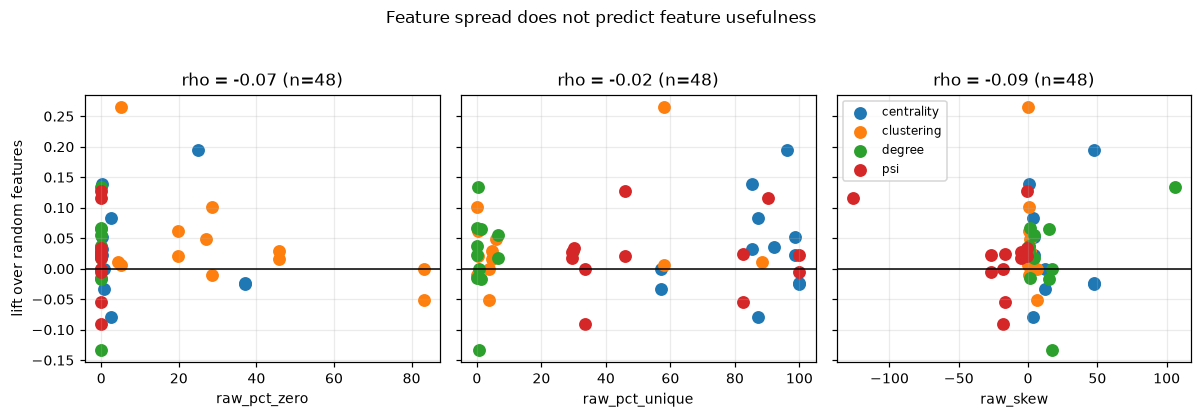

In [20]:
"""Raw distribution statistics against measured usefulness - the test the degenerate flag would have to pass."""

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)

for ax, p in zip(axes, ["raw_pct_zero", "raw_pct_unique", "raw_skew"]):

    r = corr[(corr["scope"].str.startswith("feature")) & (corr["task_family"] == "pooled")

             & (corr["predictor"] == p)].iloc[0]

    for arm, g in S.groupby("arm"):

        ax.scatter(g[p], g["lift_vs_random"], s=55, label=arm)

    ax.axhline(0, color="k", lw=1)

    ax.set(xlabel=p, title=f"rho = {r.spearman_rho:+.2f} (n={r.n})")

axes[0].set_ylabel("lift over random features")

axes[-1].legend(fontsize=8)

fig.suptitle("Feature spread does not predict feature usefulness", y=1.04)

show(fig, "fig5_spread_vs_usefulness")